In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import yfinance as yf
# !pip install streamlit
import streamlit as st

## Task-01. House Price Prediction System

In [ ]:
df = pd.read_csv('house_data.csv')
df.head()

,build_year,lat,living_area,long,municipality_name,zipcode,num_rooms,object_type_name,price,water_percentage_1000,travel_time_private_transport,travel_time_public_transport,number_of_buildings_in_hectare,number_of_apartments_in_hectare,number_of_workplaces_in_hectare,number_of_workplaces_sector_1_in_hectare,number_of_workplaces_sector_2_in_hectare,number_of_workplaces_sector_3_in_hectare,population_in_hectare
0,1990,47.009808,110.0,8.483789,Vitznau,6354,3.0,Wohnung,815000.0,0.400565,35.0,102.0,10,26.0,7,0,0,7,34
1,2017,46.872177,120.0,9.880183,Klosters-Serneus,7250,3.0,Wohnung,890000.0,0.008272,85.0,112.0,7,54.0,3,0,0,3,44
2,2010,46.519173,107.0,6.525882,Préverenges,1028,4.0,Wohnung,870000.0,0.140534,9.0,25.0,5,39.0,3,0,3,0,89
3,2018,47.521343,103.0,8.536971,Bülach,8180,3.0,Wohnung,829000.0,0.003954,14.0,18.0,2,2.0,3,0,3,0,4
4,2007,46.510216,95.0,9.852427,Celerina/Schlarigna,7505,3.0,Wohnung,865000.0,0.011116,101.0,198.0,9,45.0,3,0,3,3,85


In [ ]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print(df.duplicated().sum())

non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Non-numeric columns: {non_numeric_columns}")

if non_numeric_columns:
  df = pd.get_dummies(df, columns=non_numeric_columns, drop_first=True)

if 'price' not in df.columns:
  raise KeyError("The dataset does not contain a 'price' column. Please check the CSV file.")

(22570, 19)
Index(['build_year', 'lat', 'living_area', 'long', 'municipality_name',
       'zipcode', 'num_rooms', 'object_type_name', 'price',
       'water_percentage_1000', 'travel_time_private_transport',
       'travel_time_public_transport', 'number_of_buildings_in_hectare',
       'number_of_apartments_in_hectare', 'number_of_workplaces_in_hectare',
       'number_of_workplaces_sector_1_in_hectare',
       'number_of_workplaces_sector_2_in_hectare',
       'number_of_workplaces_sector_3_in_hectare', 'population_in_hectare'],
      dtype='object')
build_year                                  0
lat                                         0
living_area                                 0
long                                        0
municipality_name                           0
zipcode                                     0
num_rooms                                   0
object_type_name                            0
price                                       0
water_percentage_1000     

In [ ]:
X = df.drop(columns=['price'])
y = df['price']

if not np.issubdtype(X.dtypes.values[0], np.number):
  raise ValueError("Some features are still non-numeric. Check the dataset preprocessing.")

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state = 1)

In [ ]:
model = LinearRegression()
model.fit(Xtrain,ytrain)

y_pred = model.predict(Xtest)

mse = mean_squared_error(ytest,y_pred)
r2 = r2_score(ytest,y_pred)

print(f'Model Evaluation:\nMSE: {mse:.2f}, R-squared: {r2:.2f}')

Model Evaluation:
MSE: 152853244538.36, R-squared: 0.51


## Task-02. Salary Prediction System

In [2]:
df = pd.read_csv('salary_data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
print(df.shape)
print(df.columns)
print("null values:",df.isnull().sum())
print("duplicate values:",df.duplicated().sum())

(30, 2)
Index(['YearsExperience', 'Salary'], dtype='object')
null values: YearsExperience    0
Salary             0
dtype: int64
duplicate values: 0


In [4]:
X = df.drop(columns=['Salary'])
y = df['Salary']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state = 7)

model = LinearRegression()
model.fit(Xtrain,ytrain)

y_pred = model.predict(Xtest)

mse = mean_squared_error(ytest,y_pred)
r2 = r2_score(ytest,y_pred)

print(f'Model Evaluation:\nMSE: {mse:.2f}, R-squared: {r2:.2f}')

Model Evaluation:
MSE: 26602436.48, R-squared: 0.96


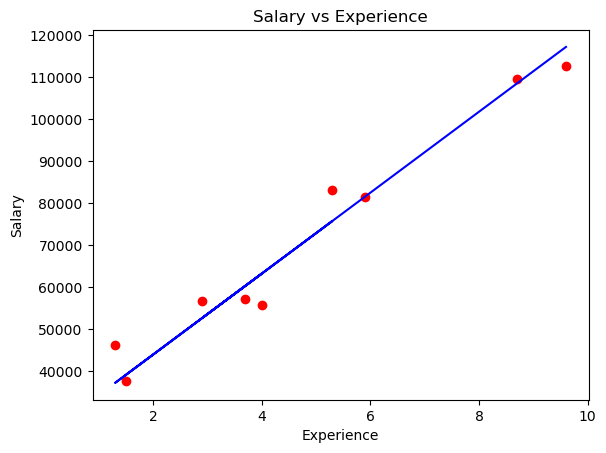

In [5]:
plt.scatter(Xtest,ytest,color='red')
plt.plot(Xtest,y_pred,color='blue')
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [6]:
import pickle

with open('salary_model.pkl','wb') as file:
    pickle.dump(model,file)

## TASK-03. Stock Price Trend Prediction

2025-03-11 19:43:13.202 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 19:43:13.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 19:43:13.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 19:43:13.208 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 19:43:13.211 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 19:43:13.212 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 19:43:13.258 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


MSE: 272.9433670361602, R-squared: 0.8392993704666822


2025-03-11 19:43:13.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 19:43:13.529 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

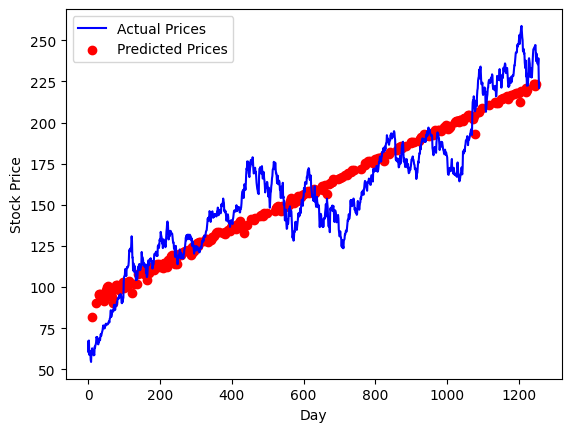

In [ ]:
# Fetch stock data
def get_stock_data(ticker):
    stock = yf.Ticker(ticker)
    df = stock.history(period='5y')
    df = df[['Close', 'Volume']].dropna()
    df['Day'] = np.arange(len(df))
    return df

# Load dataset
ticker = 'AAPL'  # Example stock symbol
df = get_stock_data(ticker)

# Define features and target variable
X = df[['Day', 'Volume']]
y = df['Close']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse}, R-squared: {r2}')

# Streamlit app for visualization
st.title('Stock Price Trend Prediction')
st.write(f'Stock: {ticker}')
fig, ax = plt.subplots()
ax.plot(df['Day'], df['Close'], label='Actual Prices', color='blue')
ax.scatter(X_test['Day'], y_pred, label='Predicted Prices', color='red')
ax.set_xlabel('Day')
ax.set_ylabel('Stock Price')
ax.legend()
st.pyplot(fig)


## TASK-04. Customer Churn Prediction for a Subscription Service.

In [5]:
data = pd.read_csv('Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(data.shape)
print(data.columns)
print("null values:",data.isnull().sum())
print("duplicate values:",data.duplicated().sum())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
null values: customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
duplicate values: 0


In [7]:
data.drop(columns=['customerID'],inplace=True)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data['Churn'] = data['Churn'].astype(str).str.strip().map({'No': 0, 'Yes':1})

SeniorCitizen              0
tenure                     2
MonthlyCharges         53.85
Churn                    NaN
gender_Male             True
                       ...  
TotalCharges_997.75    False
TotalCharges_998.1     False
TotalCharges_999.45    False
TotalCharges_999.8     False
TotalCharges_999.9     False
Name: 2, Length: 6560, dtype: object


In [ ]:
categorical_Columns = data.select_dtypes(include=['object']).columns.tolist()
print(categorical_Columns)

data = pd.get_dummies(data,categorical_Columns,drop_first=True)
print(data.shape)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
(7043, 6560)


In [10]:
X = data.drop(columns=['Churn'])
y = data['Churn']

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2,random_state=1)

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(Xtrain,ytrain)

LogisticRegression(max_iter=1000)

In [15]:
ypred = model.predict(Xtest)

accuracy = accuracy_score(ytest,ypred)
report = classification_report(ytest,ypred)

print(f"Accuracy: {accuracy:.2f}\n")
print(report)


Accuracy: 0.81

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1061
           1       0.63      0.58      0.60       348

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409



2025-03-14 18:25:57.436 
  command:

    streamlit run C:\Users\PMLS\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()

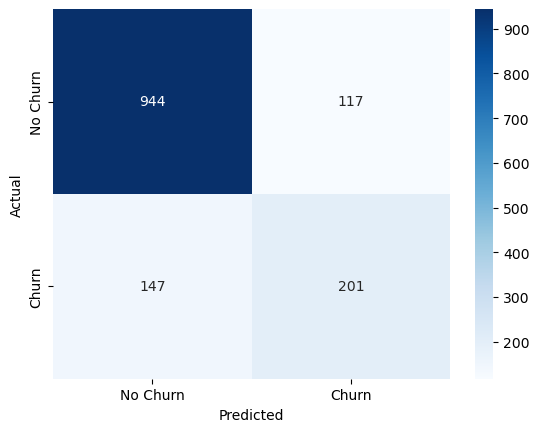

In [17]:
# Confusion Matrix Visualization
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(ytest, ypred), annot=True, fmt='d',
cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn',
'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
st.pyplot(fig)

In [18]:
import pickle

with open('churn_model.pkl','wb') as file:
    pickle.dump(model,file)

# Save feature names
with open("churn_feature_names.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

## TASK-05. Energy Consumption Prediction.

In [2]:
df = pd.read_csv("owid-energy-data.csv")
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [ ]:
# Display column names to check the correct column name for energy consumption
print("Dataset Columns:", df.columns.tolist())

# Identify the correct column for energy consumption
energy_columns = [col for col in df.columns if "consumption" in col.lower()]

if not energy_columns:
  raise KeyError("No column related to energy consumption found in the dataset.")

# Use the first identified energy consumption column
energy_column = energy_columns[0]
print(f"Using '{energy_column}' as the target variable.")

Dataset Columns: ['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh', 'gas_consumption', 'gas_el

In [4]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print(df.duplicated().sum())

(21812, 129)
Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=129)
country                       0
year                          0
iso_code                   5000
population                 3365
gdp                       10037
                          ...  
wind_elec_per_capita      14534
wind_electricity          13578
wind_energy_per_capita    17659
wind_share_elec           14615
wind_share_energy         17619
Length: 129, dtype: int64
0


In [5]:
df.dropna(inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
  df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.isnull().sum())

year                       0
population                 0
gdp                        0
biofuel_cons_change_pct    0
biofuel_cons_change_twh    0
                          ..
iso_code_ROU               0
iso_code_SVK               0
iso_code_SVN               0
iso_code_UKR               0
iso_code_USA               0
Length: 149, dtype: int64


In [6]:
df.shape

(138, 149)

In [10]:
X = df.drop(columns=[energy_column])
y = df[energy_column]

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state = 7)

In [11]:
model = LinearRegression()
model.fit(Xtrain,ytrain)

y_pred = model.predict(Xtest)

mse = mean_squared_error(ytest,y_pred)
r2 = r2_score(ytest,y_pred)

print(f'Model Evaluation:\nMSE: {mse:.2f}, R-squared: {r2:.2f}')

Model Evaluation:
MSE: 0.05, R-squared: 1.00


DeltaGenerator()

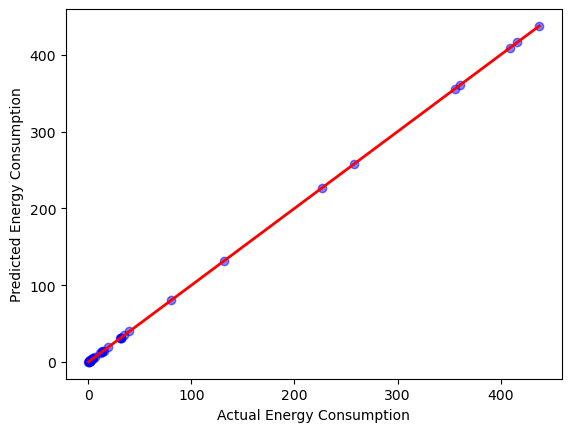

In [12]:
# Streamlit app
st.title('Energy Consumption Prediction')
st.write(f'MSE: {mse:.2f}, R-squared: {r2:.2f}')

# Visualization
fig, ax = plt.subplots()
ax.scatter(ytest, y_pred, alpha=0.5, color='blue')
ax.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r',lw=2)
ax.set_xlabel('Actual Energy Consumption')
ax.set_ylabel('Predicted Energy Consumption')
st.pyplot(fig)

In [14]:
# User input for prediction
st.sidebar.header('Predict Energy Consumption')
features = {col: st.sidebar.number_input(f'Enter {col}:',
float(df[col].min()), float(df[col].max())) for col in X.columns}
if st.sidebar.button('Predict'):
    input_data = np.array([features[col] for col in X.columns]).reshape(1, -1)
    prediction = model.predict(input_data)[0]
    st.sidebar.write(f'Predicted Energy Consumption: {prediction:.2f} kWh')